# SkinGuard XAI Inference Notebook

This notebook is used for prediction only.

The training notebook created and saved the model.  
This inference notebook loads the trained model and predicts the skin lesion class from a new image.

## Workflow

1. Load trained model
2. Load class names
3. Select a skin lesion image
4. Preprocess the image
5. Predict lesion class
6. Show confidence score
7. Display medical disclaimer

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow Version:", tf.__version__)

2026-06-28 16:01:52.839595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782662513.115517      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782662513.181423      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782662513.771467      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782662513.771515      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782662513.771517      16 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


## Step 1: Locate Model Files

The trained model and class names were saved from the training notebook.

For inference, we need:

- `SkinGuard_XAI_Image_Model.keras`
- `class_names.json`

The image-only model is easier for deployment because it only needs a skin image as input.

In [2]:
BASE_PATH = "/kaggle/input"

for dirname, _, filenames in os.walk(BASE_PATH):
    for filename in filenames:
        if filename.endswith(".keras") or filename.endswith(".json"):
            print(os.path.join(dirname, filename))

/kaggle/input/notebooks/rinvijaman/skinguard-xai/__output__.json
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Image_Model.keras
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Metadata_Fusion_Model.keras
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/metadata_columns.json
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/class_names.json


In [3]:
MODEL_PATH = "/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Image_Model.keras"

CLASS_NAMES_PATH = "/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/class_names.json"

## Step 2: Load the Trained Model

Now we load the trained MobileNetV2 image-only model.

This model accepts one image and predicts one of the HAM10000 lesion classes.

In [4]:
model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

print("✅ Model loaded successfully!")

print("\nClasses:")
for i, cls in enumerate(class_names):
    print(f"{i}: {cls}")

2026-06-28 16:02:29.202830: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Model loaded successfully!

Classes:
0: akiec
1: bcc
2: bkl
3: df
4: mel
5: nv
6: vasc


## Step 3: Define Class Descriptions

HAM10000 uses short labels such as `mel`, `nv`, and `bcc`.

To make the prediction easier to understand, we map each short label to its full medical name.

In [5]:
class_descriptions = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

for label in class_names:
    print(label, ":", class_descriptions.get(label, "Unknown"))

akiec : Actinic keratoses and intraepithelial carcinoma
bcc : Basal cell carcinoma
bkl : Benign keratosis-like lesions
df : Dermatofibroma
mel : Melanoma
nv : Melanocytic nevi
vasc : Vascular lesions


## Step 4: Image Preprocessing Function

The uploaded image must be prepared in the same way as the training images.

Preprocessing steps:

1. Read image
2. Convert BGR to RGB
3. Resize to 224 × 224
4. Convert image to batch format
5. Apply MobileNetV2 preprocessing

In [6]:
IMG_SIZE = 224

def preprocess_skin_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Image not found. Please check the image path.")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image_array = np.expand_dims(
        resized_image.astype("float32"),
        axis=0
    )

    image_array = preprocess_input(image_array)

    return image, resized_image, image_array

## Step 5: Prediction Function

This function takes an image path and returns:

- Predicted class
- Full medical name
- Confidence score
- Top 3 predictions

In [7]:
def predict_skin_lesion(image_path):
    original_image, resized_image, processed_image = preprocess_skin_image(image_path)

    predictions = model.predict(processed_image)

    predicted_index = np.argmax(predictions[0])

    predicted_label = class_names[predicted_index]

    predicted_name = class_descriptions.get(
        predicted_label,
        predicted_label
    )

    confidence = predictions[0][predicted_index]

    top_3_indices = np.argsort(predictions[0])[-3:][::-1]

    top_3_predictions = []

    for index in top_3_indices:
        label = class_names[index]
        name = class_descriptions.get(label, label)
        score = predictions[0][index]

        top_3_predictions.append(
            {
                "Label": label,
                "Class Name": name,
                "Confidence": score
            }
        )

    return original_image, predicted_label, predicted_name, confidence, top_3_predictions

## Step 6: Select a Test Image

For testing, use any skin lesion image.

You can use:

- An image from the HAM10000 dataset
- A manually uploaded image
- A sample image saved in the project folder

In [8]:
HAM10000_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

sample_images = []

for dirname, _, filenames in os.walk(HAM10000_PATH):
    for filename in filenames:
        if filename.endswith(".jpg"):
            sample_images.append(os.path.join(dirname, filename))

print("Number of sample images found:", len(sample_images))
print("First image:", sample_images[0])

Number of sample images found: 20030
First image: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


In [9]:
test_image_path = sample_images[0]

print("Test Image Path:", test_image_path)

Test Image Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


## Step 7: Run Prediction

Now we use the trained model to predict the lesion class of the selected image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


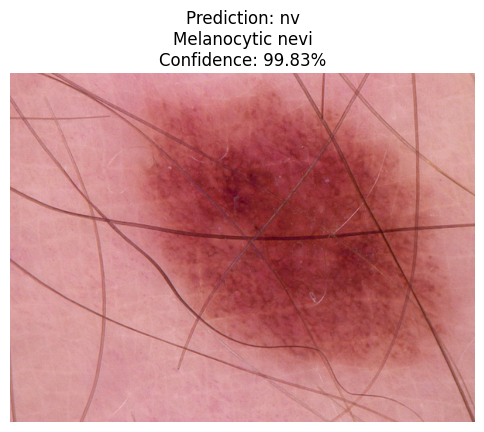

In [10]:
original_image, predicted_label, predicted_name, confidence, top_3_predictions = predict_skin_lesion(
    test_image_path
)

plt.figure(figsize=(6, 6))

plt.imshow(original_image)

plt.title(
    f"Prediction: {predicted_label}\n"
    f"{predicted_name}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")

plt.show()

## Step 8: Show Top 3 Predictions

Instead of only showing one prediction, it is better to display the top 3 predictions.

This helps users understand model uncertainty.

In [11]:
for i, prediction in enumerate(top_3_predictions, start=1):
    print(f"Top {i}")
    print("Label:", prediction["Label"])
    print("Class Name:", prediction["Class Name"])
    print("Confidence:", f"{prediction['Confidence']:.2%}")
    print()

Top 1
Label: nv
Class Name: Melanocytic nevi
Confidence: 99.83%

Top 2
Label: bkl
Class Name: Benign keratosis-like lesions
Confidence: 0.10%

Top 3
Label: mel
Class Name: Melanoma
Confidence: 0.07%



## Step 9: Save Prediction Output

We save the prediction result so it can be added to the project outputs folder.

In [12]:
import pandas as pd

os.makedirs("outputs", exist_ok=True)

prediction_df = pd.DataFrame(top_3_predictions)

prediction_df.to_csv(
    "outputs/inference_prediction.csv",
    index=False
)

prediction_df

,Label,Class Name,Confidence
0,nv,Melanocytic nevi,0.998284
1,bkl,Benign keratosis-like lesions,0.000993
2,mel,Melanoma,0.000705


## Medical Disclaimer

This project is for educational and research purposes only.

It is not a certified medical device.

It should not be used for clinical diagnosis, treatment planning, or healthcare decision-making.

Always consult qualified healthcare professionals for medical advice.

In [13]:
print("""
Medical Disclaimer:
This project is for educational and research purposes only.
It is not a certified medical device.
It should not be used for clinical diagnosis or treatment planning.
Always consult qualified healthcare professionals for medical advice.
""")


Medical Disclaimer:
This project is for educational and research purposes only.
It is not a certified medical device.
It should not be used for clinical diagnosis or treatment planning.
Always consult qualified healthcare professionals for medical advice.



# Conclusion

In this notebook, I created an inference pipeline for SkinGuard XAI.

## What this notebook does

- Loads the trained SkinGuard XAI model
- Loads HAM10000 class names
- Preprocesses a skin lesion image
- Predicts the lesion class
- Shows confidence score
- Displays top 3 predictions
- Saves prediction results

This notebook moves the project from model training toward real deployment.

The next step is to add Grad-CAM explainability and then convert this notebook into a Gradio web application.